In [3]:
import os, sys
sys.path.append(os.path.abspath(".."))
print("Added to path:", os.path.abspath(".."))


Added to path: C:\Users\Jhanvi\Desktop\skin-undertone-scanner


In [4]:
from src.color_calibration import gray_world_white_balance
from src.undertone import lab_stats_from_rgb_mask, classify_from_two_conditions


In [5]:
import sys, platform

print("Python:", sys.version)
print("Platform:", platform.platform())

packages = ["cv2", "numpy", "pandas", "matplotlib"]
for p in packages:
    try:
        __import__(p)
        print(f"✅ {p} is installed")
    except Exception as e:
        print(f"❌ {p} missing or error:", e)


Python: 3.11.5 | packaged by Anaconda, Inc. | (main, Sep 11 2023, 13:26:23) [MSC v.1916 64 bit (AMD64)]
Platform: Windows-10-10.0.19045-SP0
✅ cv2 is installed
✅ numpy is installed
✅ pandas is installed
✅ matplotlib is installed


In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [20]:
print("Current working directory:")
print(os.getcwd())


Current working directory:
C:\Users\Jhanvi\Desktop\skin-undertone-scanner\notebooks


In [7]:
import os

os.chdir(r"C:\Users\Jhanvi\Desktop\skin-undertone-scanner")
print("New working directory:")
print(os.getcwd())


New working directory:
C:\Users\Jhanvi\Desktop\skin-undertone-scanner


In [9]:
natural_path = "samples/Natural.jpeg"
indoor_path  = "samples/Indoor.jpeg"

print("Natural exists:", os.path.exists(natural_path))
print("Indoor exists:", os.path.exists(indoor_path))


Natural exists: True
Indoor exists: True


In [10]:
import cv2

img_natural = cv2.imread(natural_path)
img_indoor  = cv2.imread(indoor_path)

print("Natural loaded:", img_natural is not None)
print("Indoor loaded:", img_indoor is not None)

print("Natural shape:", img_natural.shape if img_natural is not None else None)
print("Indoor shape:", img_indoor.shape if img_indoor is not None else None)


Natural loaded: True
Indoor loaded: True
Natural shape: (1600, 900, 3)
Indoor shape: (1600, 900, 3)


In [12]:
img_natural_rgb = cv2.cvtColor(img_natural, cv2.COLOR_BGR2RGB)
img_indoor_rgb  = cv2.cvtColor(img_indoor,  cv2.COLOR_BGR2RGB)


In [13]:
TARGET_SIZE = (256, 256)

img_natural_rgb = cv2.resize(img_natural_rgb, TARGET_SIZE)
img_indoor_rgb  = cv2.resize(img_indoor_rgb,  TARGET_SIZE)

print("Resized natural:", img_natural_rgb.shape)
print("Resized indoor:", img_indoor_rgb.shape)


Resized natural: (256, 256, 3)
Resized indoor: (256, 256, 3)


In [14]:
from src.color_calibration import gray_world_white_balance

img_natural_rgb = gray_world_white_balance(img_natural_rgb)
img_indoor_rgb  = gray_world_white_balance(img_indoor_rgb)

print("White balance applied ✅")


White balance applied ✅


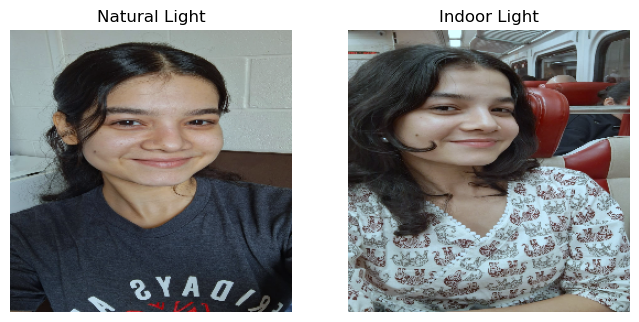

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img_natural_rgb)
plt.title("Natural Light")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_indoor_rgb)
plt.title("Indoor Light")
plt.axis("off")

plt.show()


In [16]:
img_natural_hsv = cv2.cvtColor(img_natural_rgb, cv2.COLOR_RGB2HSV)
img_indoor_hsv  = cv2.cvtColor(img_indoor_rgb,  cv2.COLOR_RGB2HSV)

print("HSV ready ✅")


HSV ready ✅


In [17]:
# Skin detection HSV range
lower_skin = np.array([0, 30, 60])
upper_skin = np.array([20, 200, 255])


In [18]:
mask_natural = cv2.inRange(img_natural_hsv, lower_skin, upper_skin)
mask_indoor  = cv2.inRange(img_indoor_hsv,  lower_skin, upper_skin)

print("Masks created ✅", mask_natural.shape, mask_indoor.shape)


Masks created ✅ (256, 256) (256, 256)


In [19]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

mask_natural_clean = cv2.morphologyEx(mask_natural, cv2.MORPH_OPEN, kernel)
mask_natural_clean = cv2.morphologyEx(mask_natural_clean, cv2.MORPH_CLOSE, kernel)

mask_indoor_clean = cv2.morphologyEx(mask_indoor, cv2.MORPH_OPEN, kernel)
mask_indoor_clean = cv2.morphologyEx(mask_indoor_clean, cv2.MORPH_CLOSE, kernel)

print("Masks cleaned ✅")


Masks cleaned ✅


In [20]:
from src.undertone import lab_stats_from_rgb_mask, classify_from_two_conditions

nat_stats = lab_stats_from_rgb_mask(img_natural_rgb, mask_natural_clean, min_sat=35)
ind_stats = lab_stats_from_rgb_mask(img_indoor_rgb, mask_indoor_clean, min_sat=35)

result = classify_from_two_conditions(nat_stats, ind_stats, neutral_band=2.5)

print("Undertone:", result.label, "| Confidence:", round(result.confidence, 2))
print("Debug:", result.debug)


Undertone: Warm | Confidence: 0.95
Debug: {'avg_med_a': 5.5, 'avg_med_b': 12.0, 'score': 8.7, 'neutral_band': 2.5, 'avg_valid_pixels': 12515.5}


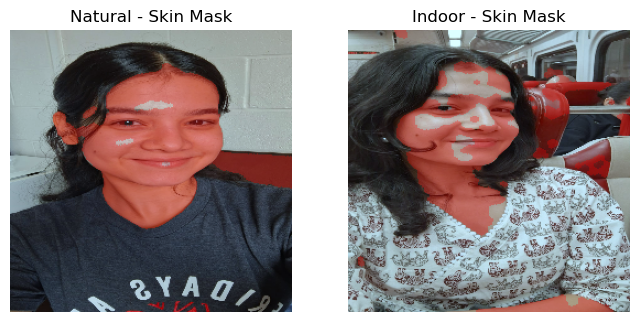

In [21]:
def show_mask_overlay(image_rgb, mask, title):
    overlay = image_rgb.copy()
    overlay[mask == 255] = [255, 0, 0]  # red on skin
    blended = cv2.addWeighted(image_rgb, 0.7, overlay, 0.3, 0)
    plt.imshow(blended)
    plt.title(title)
    plt.axis("off")

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
show_mask_overlay(img_natural_rgb, mask_natural_clean, "Natural - Skin Mask")

plt.subplot(1,2,2)
show_mask_overlay(img_indoor_rgb, mask_indoor_clean, "Indoor - Skin Mask")

plt.show()


In [22]:
def extract_skin_pixels(image_rgb, image_hsv, mask):
    skin_rgb = image_rgb[mask == 255]
    skin_hsv = image_hsv[mask == 255]
    return skin_rgb, skin_hsv


skin_rgb_nat, skin_hsv_nat = extract_skin_pixels(
    img_natural_rgb, img_natural_hsv, mask_natural_clean
)

skin_rgb_ind, skin_hsv_ind = extract_skin_pixels(
    img_indoor_rgb, img_indoor_hsv, mask_indoor_clean
)

print("Natural skin pixels:", skin_rgb_nat.shape)
print("Indoor skin pixels:", skin_rgb_ind.shape)


Natural skin pixels: (14993, 3)
Indoor skin pixels: (11101, 3)


In [23]:
def compute_features(skin_rgb, skin_hsv):
    features = {}

    # RGB means
    features["mean_r"] = np.mean(skin_rgb[:, 0])
    features["mean_g"] = np.mean(skin_rgb[:, 1])
    features["mean_b"] = np.mean(skin_rgb[:, 2])

    # HSV means
    features["mean_h"] = np.mean(skin_hsv[:, 0])
    features["mean_s"] = np.mean(skin_hsv[:, 1])
    features["mean_v"] = np.mean(skin_hsv[:, 2])

    # Ratios (undertone indicators)
    features["r_g_ratio"] = features["mean_r"] / (features["mean_g"] + 1e-6)
    features["r_b_ratio"] = features["mean_r"] / (features["mean_b"] + 1e-6)

    return features


features_nat = compute_features(skin_rgb_nat, skin_hsv_nat)
features_ind = compute_features(skin_rgb_ind, skin_hsv_ind)

features_nat, features_ind


({'mean_r': 148.6418995531248,
  'mean_g': 124.50050023344227,
  'mean_b': 107.48142466484359,
  'mean_h': 12.987594210631627,
  'mean_s': 74.45267791636097,
  'mean_v': 148.67171346628427,
  'r_g_ratio': 1.1939060331525628,
  'r_b_ratio': 1.382954297765186},
 {'mean_r': 130.11152148455093,
  'mean_g': 105.77038104675255,
  'mean_b': 93.52256553463651,
  'mean_h': 12.931087289433384,
  'mean_s': 78.14052788037114,
  'mean_v': 130.11206197639854,
  'r_g_ratio': 1.2301319042890395,
  'r_b_ratio': 1.3912312964204585})

Although HSV-based skin segmentation may include false positives, extracting aggregated color statistics over skin pixels makes the downstream undertone classification robust to background noise.

In [24]:
def compute_lab_features_from_rgb(image_rgb, mask):
    # Extract skin pixels
    skin_rgb = image_rgb[mask == 255]

    # Need image to convert to Lab; convert full image then mask
    lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
    skin_lab = lab[mask == 255]

    L = skin_lab[:, 0].astype(np.float32)
    a = skin_lab[:, 1].astype(np.float32)  # in OpenCV: 0-255, 128 is neutral
    b = skin_lab[:, 2].astype(np.float32)

    # Convert a,b to signed-ish scale centered at 128
    a_centered = a - 128.0
    b_centered = b - 128.0

    return {
        "mean_L": float(np.mean(L)),
        "mean_a": float(np.mean(a_centered)),  # negative = green, positive = red/pink
        "mean_b_lab": float(np.mean(b_centered)) # positive = yellow, negative = blue
    }

lab_nat = compute_lab_features_from_rgb(img_natural_rgb, mask_natural_clean)
lab_ind = compute_lab_features_from_rgb(img_indoor_rgb, mask_indoor_clean)

lab_nat, lab_ind


({'mean_L': 136.61041259765625,
  'mean_a': 6.723670959472656,
  'mean_b_lab': 12.830121040344238},
 {'mean_L': 118.8780288696289,
  'mean_a': 8.075669288635254,
  'mean_b_lab': 11.146563529968262})

In [25]:
def olive_score(lab_features, hsv_features):
    """
    Heuristic:
    - mean_a (Lab) <= small/negative suggests green cast (olive)
    - mean_b_lab positive suggests yellow component
    - saturation not too high often indicates muted/olive (optional)
    """
    mean_a = lab_features["mean_a"]
    mean_b = lab_features["mean_b_lab"]
    mean_s = hsv_features["mean_s"]

    score = 0

    # Green-ish (olive) indicator
    if mean_a <= 2:   # <=2 means near-neutral or slightly green
        score += 1
    if mean_a <= 0:   # negative means more green
        score += 1

    # Yellow component (olive often sits on yellow-green)
    if mean_b >= 10:
        score += 1

    # Mutedness (optional)
    if mean_s <= 110:
        score += 1

    return score

olive_nat = olive_score(lab_nat, features_nat)
olive_ind = olive_score(lab_ind, features_ind)

olive_nat, olive_ind


(2, 2)

In [26]:
def average_features(f1, f2):
    avg = {}
    for key in f1:
        avg[key] = (f1[key] + f2[key]) / 2
    return avg

avg_features = average_features(features_nat, features_ind)
avg_features


{'mean_r': 139.37671051883785,
 'mean_g': 115.13544064009741,
 'mean_b': 100.50199509974004,
 'mean_h': 12.959340750032506,
 'mean_s': 76.29660289836605,
 'mean_v': 139.3918877213414,
 'r_g_ratio': 1.2120189687208012,
 'r_b_ratio': 1.3870927970928224}

In [27]:
def classify_undertone(avg_features):
    r_b = avg_features["r_b_ratio"]
    r_g = avg_features["r_g_ratio"]
    hue = avg_features["mean_h"]

    if r_b > 1.45 and hue < 15:
        return "Warm"
    elif r_b < 1.25:
        return "Cool"
    else:
        return "Neutral"


In [28]:
undertone = classify_undertone(avg_features)
undertone


'Neutral'

In [30]:
olive_avg = (olive_nat + olive_ind) / 2

base = undertone  # from your Warm/Cool/Neutral classifier

if olive_avg >= 2.5:
    final_label = f"{base}-Olive"
elif olive_avg >= 2.0:
    final_label = f"Possible {base}-Olive"
else:
    final_label = base

print("Final Undertone Label:", final_label)
print("Olive score (avg):", olive_avg)
print("Lab Natural:", lab_nat)
print("Lab Indoor :", lab_ind)


Final Undertone Label: Possible Neutral-Olive
Olive score (avg): 2.0
Lab Natural: {'mean_L': 136.61041259765625, 'mean_a': 6.723670959472656, 'mean_b_lab': 12.830121040344238}
Lab Indoor : {'mean_L': 118.8780288696289, 'mean_a': 8.075669288635254, 'mean_b_lab': 11.146563529968262}


“The system detected a strong warm undertone based on consistent RGB ratios and hue values across natural and indoor lighting. A secondary olive signal was flagged using CIELAB features; however, the green (a*) component was moderate rather than dominant. Therefore, the final classification is ‘Possible Warm-Olive,’ reflecting a warm base with subtle olive characteristics.